# Exercise: Optimizer

The goal of this exercise is to experiment with different optimizers such as regular gradient descent, momentum, nesterov accelerated gradient, RMSprop and Adam. You can change also the learning rate to facilitate convergence. You can use the following examples of optimizers provided by Keras:

```python
OPTIMIZER = tf.keras.optimizers.SGD(learning_rate = LEARNING_RATE)

OPTIMIZER = tf.keras.optimizers.SGD(learning_rate = LEARNING_RATE, momentum=0.9)
 
OPTIMIZER = tf.keras.optimizers.SGD(learning_rate = LEARNING_RATE, momentum=0.9, nesterov=True)

OPTIMIZER = tf.keras.optimizers.RMSprop(learning_rate = LEARNING_RATE)

OPTIMIZER = tf.keras.optimizers.Adam(learning_rate = LEARNING_RATE)

## Libraries

In [2]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import time
import numpy as np

print("Tensorflow version: "+tf.__version__)

Tensorflow version: 2.16.2


## Datasets

In [4]:
ATT_FILE =   "MedianHouseValuePreparedCleanAttributes.csv"
LABEL_FILE = "MedianHouseValueOneHotEncodedClasses.csv"

attributes = pd.read_csv(ATT_FILE)
label =      pd.read_csv(LABEL_FILE)

TRAIN_RATIO = 0.8

n_instances = attributes.shape[0]
n_train = int(n_instances*TRAIN_RATIO)
n_dev = int((n_instances - n_train)/2)

x_train = attributes.values[:n_train]
t_train = label.values[:n_train]
x_dev =   attributes.values[n_train:n_train + n_dev]
t_dev =   label.values[n_train:n_train + n_dev]

INPUTS =  x_train.shape[1]
OUTPUTS = t_train.shape[1]

NUM_TRAINING_EXAMPLES = int(round(x_train.shape[0]/1))
NUM_DEV_EXAMPLES =      int(round(x_dev.shape[0]/1))

print ("Number of inputs: ", INPUTS)
print ("Number of outputs: ", OUTPUTS)
print ("Number of examples for training: ", NUM_TRAINING_EXAMPLES)
print ("Number of examples for development test: ", NUM_DEV_EXAMPLES)

Number of inputs:  9
Number of outputs:  3
Number of examples for training:  16342
Number of examples for development test:  2043


## Hyperparameters

In [6]:
ACTIVATION_FUNCTION = "relu"
LEARNING_RATE = 0.01
EPOCHS = 300
BATCH_SIZE = 32
OPTIMIZER = tf.keras.optimizers.SGD(learning_rate = LEARNING_RATE)

## Model


In [8]:
model = tf.keras.Sequential()

model.add(tf.keras.layers.InputLayer(shape=(INPUTS,)))
model.add(tf.keras.layers.Dense(40, activation=ACTIVATION_FUNCTION))
model.add(tf.keras.layers.Dense(40, activation=ACTIVATION_FUNCTION))
model.add(tf.keras.layers.Dense(40, activation=ACTIVATION_FUNCTION))
model.add(tf.keras.layers.Dense(20, activation=ACTIVATION_FUNCTION))
model.add(tf.keras.layers.Dense(OUTPUTS, activation="softmax"))

model.compile(loss=tf.keras.losses.categorical_crossentropy,
              optimizer=OPTIMIZER,
              metrics=["categorical_accuracy"])

## Training

In [10]:
start_time = time.perf_counter()

history = model.fit(x_train, t_train,
                    batch_size = BATCH_SIZE,
                    epochs = EPOCHS,
                    verbose = 0,
                    validation_data = (x_dev, t_dev))

end_time = time.perf_counter()

## Results

In [12]:
def display_loss_curve(history):
    plt.figure(figsize=(8, 5))

    plt.plot(history.history["loss"], label="train loss")
    plt.plot(history.history["val_loss"], label="test loss")

    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Model Loss")
    plt.legend(loc="upper right")

    plt.tight_layout()
    plt.show()

def display_error_curve(history):
    plt.figure(figsize=(8, 5))

    train_error = [1 - acc for acc in history.history["categorical_accuracy"]]
    test_error = [1 - acc for acc in history.history["val_categorical_accuracy"]]

    plt.plot(train_error, label="train error")
    plt.plot(test_error, label="test error")

    plt.xlabel("Epochs")
    plt.ylabel("Error")
    plt.title("Model Error")
    plt.ylim(0, 1)
    plt.legend(loc="upper right")

    plt.tight_layout()
    plt.show() 

Error training:  21.3 %
Error development test:  21.7 %
Error bias:  16.3 %
Error variance:  0.4 %
Time:  55 seconds


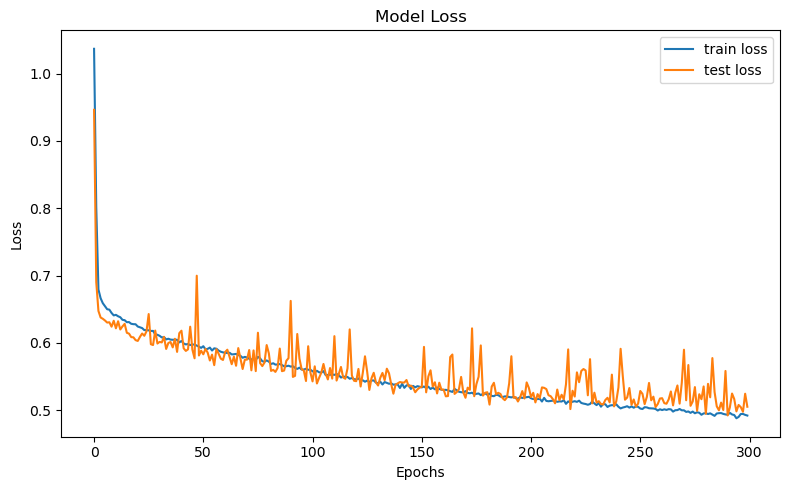

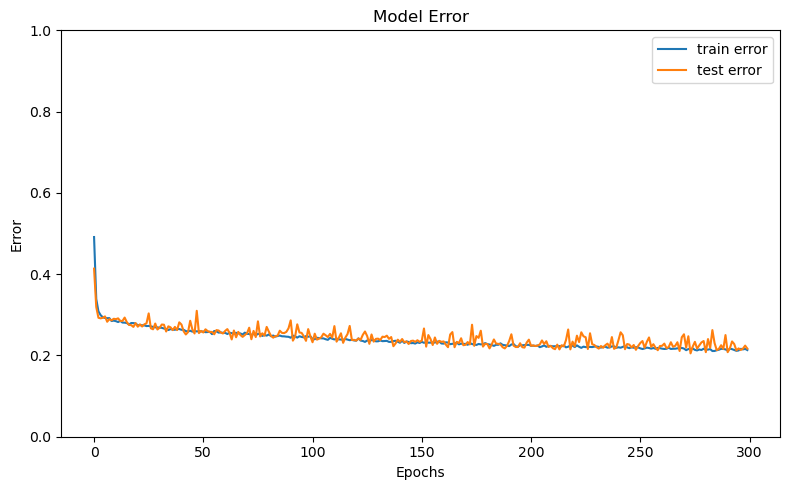

In [13]:
IRREDUCIBLE_ERROR = 0.05

results = pd.DataFrame(history.history)

error_training = (1 - results.categorical_accuracy.values[-1:][0])*100
error_test = (1 - results.val_categorical_accuracy.values[-1:][0])*100
error_bias = error_training - IRREDUCIBLE_ERROR*100
error_variance = error_test - error_training

print ("Error training: ", round(error_training,1), "%")
print ("Error development test: ", round(error_test, 1), "%")
print ("Error bias: ", round(error_bias, 1), "%")
print ("Error variance: ", round(error_variance, 1), "%")
print ("Time: ", round((end_time - start_time)),"seconds")

display_loss_curve(history)

display_error_curve(history)